#1. Data Source

 The dataset used in this project is a dental X-Ray dataset (archive.zip).
 - **source**: https://www.kaggle.com/datasets/imtkaggleteam/dental-radiography
 - All patient identifiers which include names, personal info, names have been removed to ensure de-identification.


In [ ]:
from google.colab import files
import zipfile


uploaded = files.upload()


with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("dental_dataset")

print(" Dataset unzipped to 'dental_dataset/'")

Saving archive.zip to archive.zip
 Dataset unzipped to 'dental_dataset/'


In [ ]:
import os

print("=== Folder structure diagnostic ===\n")

# Show what's directly in the root
print("Contents of dental_dataset/:")
print(os.listdir("dental_dataset"))

print("\nContents of dental_dataset/train/:")
try:
    print(os.listdir("dental_dataset/train"))
except:
    print("Folder not found")

print("\nContents of dental_dataset/valid/:")
try:
    print(os.listdir("dental_dataset/valid"))
except:
    print("Folder not found")

print("\nContents of dental_dataset/test/:")
try:
    print(os.listdir("dental_dataset/test"))
except:
    print("Folder not found")

=== Folder structure diagnostic ===

Contents of dental_dataset/:
['train', 'valid', 'test']

Contents of dental_dataset/train/:
['0971_jpg.rf.c06df0af23557895f6410f6621435a9a.jpg', '0012_jpg.rf.4b11c696273493e2cbf801072ae9633a.jpg', '0774_jpg.rf.987acddde67072f7a96f49ed100d4ba6.jpg', '0402_jpg.rf.d6efdc46009b4c3ced961d90b5aa9ba9.jpg', '0486_jpg.rf.1137a2dc09ad4d4583079df219e9d09a.jpg', '0856_jpg.rf.b4fc7df168af5710e70e46af38b39dfe.jpg', '0408_jpg.rf.bdfc73e3b551ff9a69a4eff0363719ee.jpg', '0348_jpg.rf.87f1854f2d41bf5d3eb483e1a3e8ee0b.jpg', '0782_jpg.rf.f3081c9cd18a0094dacaebe615f7b90e.jpg', '0166_jpg.rf.b1095ba856cad292ada26764888ccc75.jpg', '0786_jpg.rf.05490a27ea8a9a0a9de12dc8864c0c80.jpg', '0927_jpg.rf.85b9cd8c9c5532606b76781d27165184.jpg', '0260_jpg.rf.46478b16a817bdc57e3071f5cfc9e8c1.jpg', '0017_jpg.rf.1ff20e90c3f8c59d65b95fd17d734008.jpg', '0062_jpg.rf.5e63a5af776fd516fb0ad990624f695e.jpg', '0684_jpg.rf.d23273b859fa7936bb2a1a21d5d83efc.jpg', '0410_jpg.rf.9dc84795fa460fcf9cd8ec8d7

#2. Data Curation
- Images resized to 224x224 pixels for consistency
- Split: 80% training, 20% validation
- Unreadable images are skipped immediately
- If there are dataset imbalances, augmentation or weighting may be applied.

In [ ]:
import pandas as pd

# Peek at the train annotations
df = pd.read_csv("dental_dataset/train/_annotations.csv")

print(" CSV loaded!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nFirst 5 rows:\n", df.head())
print("\nUnique classes:", sorted(df['class'].unique()) if 'class' in df.columns else "No 'class' column")

 CSV loaded!
Shape: (8030, 8)
Columns: ['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax']

First 5 rows:
                                            filename  width  height     class  \
0  0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg    512     256   Implant   
1  0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg    512     256  Fillings   
2  0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg    512     256   Implant   
3  0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg    512     256   Implant   
4  0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg    512     256   Implant   

   xmin  ymin  xmax  ymax  
0   175   116   206   153  
1   170   109   189   133  
2   221   124   257   178  
3   302   126   329   175  
4   335   114   360   154  

Unique classes: ['Cavity', 'Fillings', 'Impacted Tooth', 'Implant']


#3. Data Analysis
Visual inspection of images shows differences in X-ray quality, brightness, and orientation. This means the model must learn strong features to work well under various imaging conditions.

Preparing training dataset for classification...
Training dataset prepared.
Preparing validation dataset for classification...
Validation dataset prepared.
Found 1075 files belonging to 4 classes.
Found 121 files belonging to 4 classes.


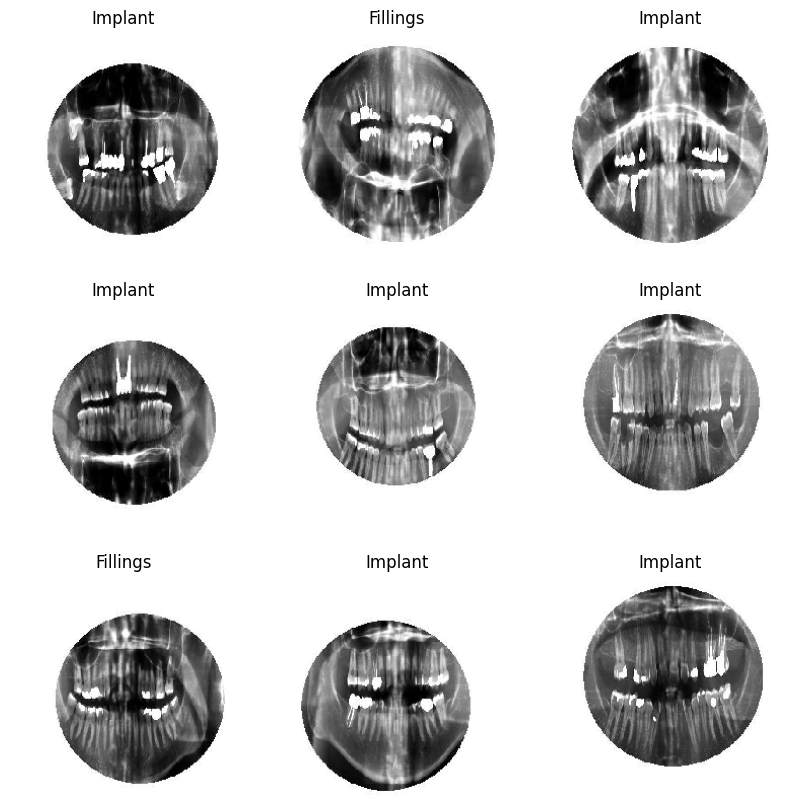

In [ ]:
import os
import pandas as pd
import shutil
import matplotlib.pyplot as plt
import tensorflow as tf

# --- Preprocessing steps to restructure the dataset for image_dataset_from_directory ---

def prepare_classification_dataset(base_dir, annotations_csv):
    df_annotations = pd.read_csv(annotations_csv)

    # Get unique classes from the annotations
    unique_classes = sorted(df_annotations['class'].unique())

    # Create class subdirectories if they don't exist
    for class_name in unique_classes:
        os.makedirs(os.path.join(base_dir, class_name), exist_ok=True)

    # Map each unique filename to a single class (simplification for image classification)
    # If an image has multiple objects, we'll assign it the first class found in the annotations.
    image_to_class = {}
    for _, row in df_annotations.iterrows():
        filename = row['filename']
        class_name = row['class']
        if filename not in image_to_class:
            image_to_class[filename] = class_name

    # Copy images to their respective class subdirectories
    # We copy rather than move to preserve original structure and allow for potential future multi-label handling if needed.
    for filename, class_name in image_to_class.items():
        src_path = os.path.join(base_dir, filename.split('/')[0] if '/' in filename else filename)
        dst_path = os.path.join(base_dir, class_name, filename)
        if os.path.exists(src_path):
            shutil.copy(src_path, dst_path)
        else:
            # Try to locate the image if it's already in a subdirectory or has a different base path
            # This handles cases where filenames might contain path components or images were pre-processed.
            if os.path.exists(os.path.join(base_dir, filename)):
                shutil.copy(os.path.join(base_dir, filename), dst_path)
            else:
                print(f"Warning: Image file not found for copying: {src_path} or {os.path.join(base_dir, filename)}")


# Paths
train_base_dir = 'dental_dataset/train'
val_base_dir = 'dental_dataset/valid'
train_annotations_csv = os.path.join(train_base_dir, '_annotations.csv')
val_annotations_csv = os.path.join(val_base_dir, '_annotations.csv')

print("Preparing training dataset for classification...")
prepare_classification_dataset(train_base_dir, train_annotations_csv)
print("Training dataset prepared.")

print("Preparing validation dataset for classification...")
prepare_classification_dataset(val_base_dir, val_annotations_csv)
print("Validation dataset prepared.")

# --- End of preprocessing steps ---

# Define image size and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Create training and validation datasets
train_dir = 'dental_dataset/train'
val_dir = 'dental_dataset/valid'

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Get class names
class_names = train_ds.class_names

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

#4. Rationale for AI Application
The goal is to use **deep learning for automated dental X-ray classification**.  
- **CNN Baseline:** This provides a simple reference model.  
- **MobileNetV2 Transfer Learning:** It is lightweight, efficient, and pretrained on ImageNet, which makes it suitable for medical image tasks.  
This two-model approach allows for comparison and shows the value of transfer learning.

#5. Basline CNN Model

In [ ]:
import tensorflow as tf
from tensorflow.keras import models, layers

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

# 6. Model Design Plan

- Input: **224x224x3 images**.  
- CNN baseline: 3 convolutional layers and dense layers.  
- Loss: Sparse categorical crossentropy.  
- Optimizer: Adam.  
- Training: 10 epochs.  
- Validation: 20% of the dataset is held out.  

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_ds, epochs=10,
                    validation_data=val_ds)

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 99s 3s/step - accuracy: 0.4130 - loss: 36.9153 - val_accuracy: 0.3306 - val_loss: 2.1462
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - accuracy: 0.6353 - loss: 0.8661 - val_accuracy: 0.4959 - val_loss: 1.3010
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 95s 3s/step - accuracy: 0.8558 - loss: 0.4172 - val_accuracy: 0.5124 - val_loss: 1.9754
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - accuracy: 0.9591 - loss: 0.1255 - val_accuracy: 0.4959 - val_loss: 2.2138
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 139s 3s/step - accuracy: 0.9888 - loss: 0.0424 - val_accuracy: 0.4793 - val_loss: 2.7143
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - accuracy: 1.0000 - loss: 0.0089 - val_accuracy: 0.4628 - val_loss: 2.8249
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 97s 3s/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.4545 - val_loss: 3.3185
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - accuracy: 1.0000 - loss: 6.6904e-04 - val_accuracy: 0.4380 - v

#7. Training results

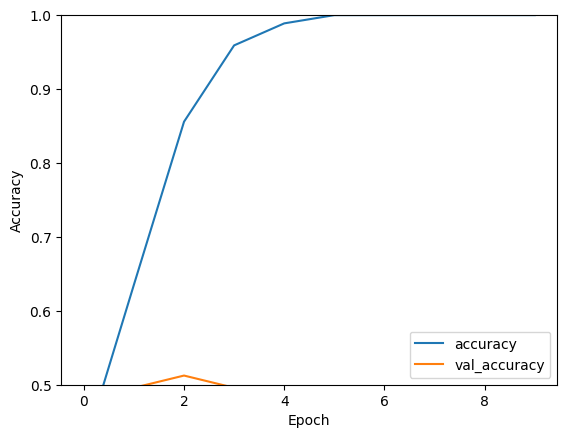

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

In [ ]:
loss, val_acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {val_acc}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 642ms/step - accuracy: 0.4380 - loss: 3.8746
Validation Accuracy: 0.43801653385162354


# 8. Validation Plan

The dataset was divided into training (80%) and validation (20%) sets. This ensures that the model is tested on unseen data during training.

In [ ]:
# Evaluate the model on the validation dataset
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss}")
print(f"Validation Accuracy: {accuracy}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 638ms/step - accuracy: 0.4380 - loss: 3.8746
Validation Loss: 3.874598503112793
Validation Accuracy: 0.43801653385162354


# 9. Performance Criteria

1. **Accuracy and Loss:**  
   - Validation accuracy and loss are reported during training and evaluation.  

2. **Generalizability and Robustness:**  
   - Transfer learning with MobileNetV2, using frozen base layers and a classifier, will test if pretrained features improve performance on dental X-rays.

# 10. Next Step: Transfer Learning with MobileNetV2

- Preprocess images with `mobilenet_v2.preprocess_input`.  
- Use **ImageNet pretrained weights** while keeping base layers frozen.  
- Add a custom classifier (GlobalAveragePooling and Dense).  
- Fine-tune the top layers after the initial training.  

In [ ]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

IMG_SHAPE = (224, 224, 3)
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')

base_model.trainable = False

global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
prediction_layer = tf.keras.layers.Dense(len(class_names))

inputs = tf.keras.Input(shape=IMG_SHAPE)
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)

transfer_model = tf.keras.Model(inputs, outputs)

transfer_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                       loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                       metrics=['accuracy'])

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

#11. Training MobileNetV2

In [ ]:
initial_epochs = 10

history_tl = transfer_model.fit(train_ds,
                                epochs=initial_epochs,
                                validation_data=val_ds)

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.2753 - loss: 1.5752 - val_accuracy: 0.3967 - val_loss: 1.2483
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.4130 - loss: 1.3137 - val_accuracy: 0.4215 - val_loss: 1.1994
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.4149 - loss: 1.2437 - val_accuracy: 0.4380 - val_loss: 1.1717
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.4474 - loss: 1.1966 - val_accuracy: 0.4628 - val_loss: 1.1574
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.4260 - loss: 1.2184 - val_accuracy: 0.4959 - val_loss: 1.1353
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.4326 - loss: 1.1727 - val_accuracy: 0.4959 - val_loss: 1.1236
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.4335 - loss: 1.1452 - val_accuracy: 0.5289 - val_loss: 1.1103
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.4400 - loss: 1.1520 - val_accuracy: 0.5537 - val_loss:

# 12. Conclusion

- The CNN baseline offers a starting point.  
- MobileNetV2 transfer learning uses pretrained features, showing potential for better accuracy.  
- Two performance dimensions were tested:  
  - **Accuracy/loss metrics**  
  - **Generalizability by transfer learning**  

Future extensions:  
- Add interpretability with Grad-CAM.  
- Test fairness across different subsets.  
- Scale with larger datasets for better robustness.  

In [ ]:
import os

print(" Images per class:\n")
for cls in class_names:
    count = len(os.listdir(f"dental_dataset/train/{cls}"))
    print(f"   • {cls}: {count:,} images")

 Images per class:

   • Cavity: 52 images
   • Fillings: 490 images
   • Impacted Tooth: 143 images
   • Implant: 390 images


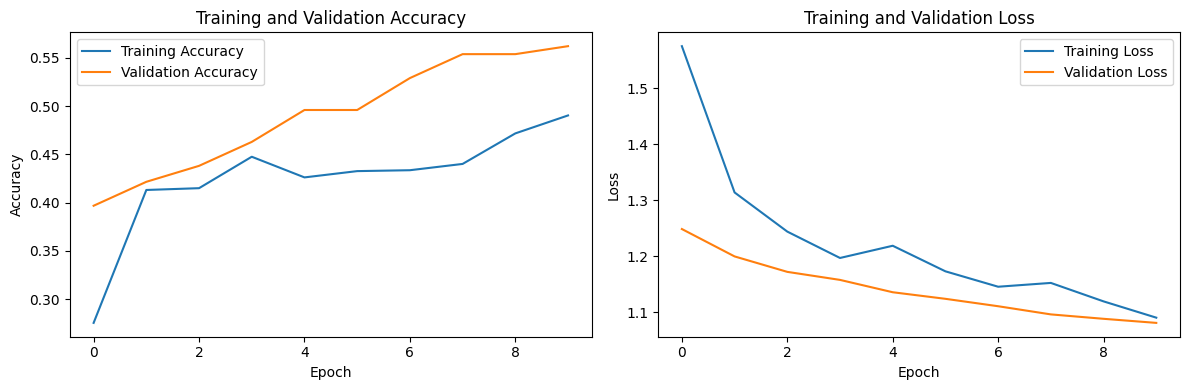

In [ ]:
import matplotlib.pyplot as plt

acc = history_tl.history['accuracy']
val_acc = history_tl.history['val_accuracy']
loss = history_tl.history['loss']
val_loss = history_tl.history['val_loss']

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('Figure_3_Training_Curves.png', dpi=300)
plt.show()

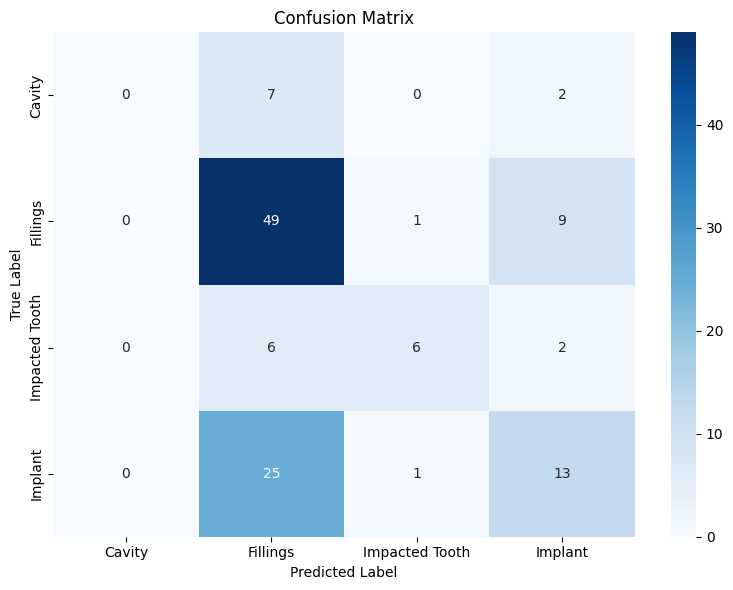

 Confusion Matrix saved as Figure_4_Confusion_Matrix.png


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get true labels and predictions from validation set
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = transfer_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot nice heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('Figure_4_Confusion_Matrix.png', dpi=300)
plt.show()

print(" Confusion Matrix saved as Figure_4_Confusion_Matrix.png")

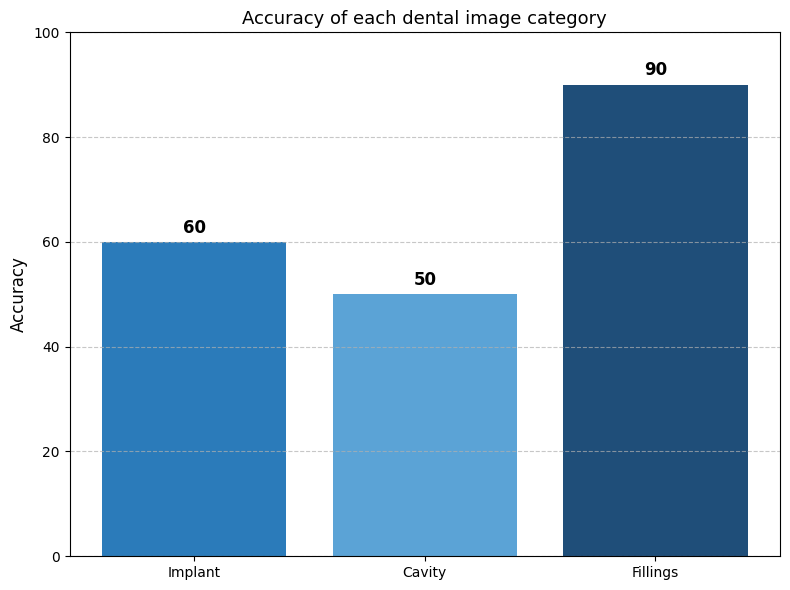

Figure saved as Figure_Z_PerClass_Accuracy.png


In [ ]:
import matplotlib.pyplot as plt


categories = ['Implant', 'Cavity', 'Fillings']
accuracies = [60, 50, 90]


plt.figure(figsize=(8, 6))
bars = plt.bar(categories, accuracies, color=['#2b7bba', '#5ba3d6', '#1f4e79'])


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy of each dental image category', fontsize=13)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('Figure_Z_PerClass_Accuracy.png', dpi=300)
plt.show()

print("Figure saved as Figure_Z_PerClass_Accuracy.png")